In [179]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import enum



# === INPUTS ===
model_path = "/Users/wachiii/Workschii/brain-asd/model/19chConfig_1 16-35-08-255/20250406_30s_30s_bandpower_relativepower_subbandpower_hfd/AdaBoost_NoFeatureSelection/model_fold_1.pkl"  # <-- CHANGE THIS
featuresDirPath = "/Users/wachiii/Workschii/brain-asd/data/data_lancaster/features"  # <-- CHANGE THISl
whichFeatureType = "bandpower_relativepower_subbandpower_hfd"  # e.g., "bandpower", "coherence", etc.
whichDirForModelPath = "/Users/wachiii/Workschii/brain-asd/model/test_lancaster"  
modelName = "AdaBoost3535"  # e.g., "RandomForest", etc.

In [180]:
class BrainMasterMontage(enum.Enum):
    Fp1 = 1
    F3 = 2
    C3 = 3
    P3 = 4
    O1 = 5
    F7 = 6
    T3 = 7
    T5 = 8
    Fz = 9
    Fp2 = 10
    F4 = 11
    C4 = 12
    P4 = 13
    O2 = 14
    F8 = 15
    T4 = 16
    T6 = 17
    Cz = 18
    Pz = 19


featuresTypePathDict = {
    "bandpower": "/bandpower/",
    "coherence": "/coherence/",
    "hfd": "/hfd/",
    "relativepower": "/relativepower/",
    "cd": "/cd/", 
    "subbandpower": "/subbandpower/",
    "alphabeta": "/alphabeta/"  }


channelsSelectedSetDict = {
    "19chConfig_1": [BrainMasterMontage.Fp1.value, BrainMasterMontage.F3.value, BrainMasterMontage.C3.value, BrainMasterMontage.P3.value,
                        BrainMasterMontage.O1.value, BrainMasterMontage.F7.value, BrainMasterMontage.T3.value, BrainMasterMontage.T5.value,
                        BrainMasterMontage.Fz.value, BrainMasterMontage.Fp2.value, BrainMasterMontage.F4.value, BrainMasterMontage.C4.value,
                        BrainMasterMontage.P4.value, BrainMasterMontage.O2.value, BrainMasterMontage.F8.value, BrainMasterMontage.T4.value,
                        BrainMasterMontage.T6.value, BrainMasterMontage.Cz.value, BrainMasterMontage.Pz.value]}

In [181]:
def get_feature(featureTypes, dataFeaturesDirPath, threshold=3):
    featuresPathDict = {}
    for featureType in featureTypes:
        featuresPathDict[f"hc{featureType.capitalize()}dataUnseenFeaturesPath"] = (
            dataFeaturesDirPath + featuresTypePathDict[featureType] + f"{featureType}_HC_unseen.npy")
        featuresPathDict[f"asd{featureType.capitalize()}dataUnseenFeaturesPath"] = (
            dataFeaturesDirPath + featuresTypePathDict[featureType] + f"{featureType}_ASD_unseen.npy")

    hcUnseenFeaturesDict, asdUnseenFeaturesDict = {}, {}

    for featureType in featureTypes:
        try:
            hcUnseenFeatures = np.load(featuresPathDict[f"hc{featureType.capitalize()}dataUnseenFeaturesPath"])
            asdUnseenFeatures = np.load(featuresPathDict[f"asd{featureType.capitalize()}dataUnseenFeaturesPath"])

            min_dim_hc_unseen = hcUnseenFeatures.shape[1]
            hcUnseenFeatures = hcUnseenFeatures[:, :min_dim_hc_unseen]
            min_dim_asd_unseen = asdUnseenFeatures.shape[1]
            asdUnseenFeatures = asdUnseenFeatures[:, :min_dim_asd_unseen]

            hcUnseenFeaturesDict[f"hc{featureType.capitalize()}UnseenFeatures"] = hcUnseenFeatures
            asdUnseenFeaturesDict[f"asd{featureType.capitalize()}UnseenFeatures"] = asdUnseenFeatures
        except FileNotFoundError as e:
            print(f"File not found: {e}")


    # Find the minimum number of samples across all HC and ASD features
    min_hc_unseen_samples = min([hcUnseenFeaturesDict[key].shape[0] for key in hcUnseenFeaturesDict.keys()])
    min_asd_unseen_samples = min([asdUnseenFeaturesDict[key].shape[0] for key in asdUnseenFeaturesDict.keys()])

    # Truncate features to the minimum number of samples
    for key in hcUnseenFeaturesDict.keys():
        hcUnseenFeaturesDict[key] = hcUnseenFeaturesDict[key][:min_hc_unseen_samples]
    for key in asdUnseenFeaturesDict.keys():
        asdUnseenFeaturesDict[key] = asdUnseenFeaturesDict[key][:min_asd_unseen_samples]

    # === Balance unseen features to have equal number of samples ===
    if len(hcUnseenFeaturesDict) > 0 and len(asdUnseenFeaturesDict) > 0:
        hc_keys = list(hcUnseenFeaturesDict.keys())
        asd_keys = list(asdUnseenFeaturesDict.keys())
        min_unseen = min(
            min([hcUnseenFeaturesDict[k].shape[0] for k in hc_keys]),
            min([asdUnseenFeaturesDict[k].shape[0] for k in asd_keys])
        )
        for k in hc_keys:
            if hcUnseenFeaturesDict[k].shape[0] > min_unseen:
                idx = np.random.choice(hcUnseenFeaturesDict[k].shape[0], min_unseen, replace=False)
                hcUnseenFeaturesDict[k] = hcUnseenFeaturesDict[k][idx]
        for k in asd_keys:
            if asdUnseenFeaturesDict[k].shape[0] > min_unseen:
                idx = np.random.choice(asdUnseenFeaturesDict[k].shape[0], min_unseen, replace=False)
                asdUnseenFeaturesDict[k] = asdUnseenFeaturesDict[k][idx]

    for key in hcUnseenFeaturesDict.keys():
        if len(hcUnseenFeaturesDict[key].shape) == 3:
            hcUnseenFeaturesDict[key] = hcUnseenFeaturesDict[key].reshape(hcUnseenFeaturesDict[key].shape[0], -1)
    for key in asdUnseenFeaturesDict.keys():
        if len(asdUnseenFeaturesDict[key].shape) == 3:
            asdUnseenFeaturesDict[key] = asdUnseenFeaturesDict[key].reshape(asdUnseenFeaturesDict[key].shape[0], -1)

    # Concatenate features across types
    hcFeatureUnseen = np.concatenate([hcUnseenFeaturesDict[key] for key in hcUnseenFeaturesDict.keys()], axis=1)
    asdFeatureUnseen = np.concatenate([asdUnseenFeaturesDict[key] for key in asdUnseenFeaturesDict.keys()], axis=1)

    min_unseen_samples = min(hcFeatureUnseen.shape[0], asdFeatureUnseen.shape[0])
    hcFeatureUnseen = hcFeatureUnseen[:min_unseen_samples]
    asdFeatureUnseen = asdFeatureUnseen[:min_unseen_samples]

    return hcFeatureUnseen, asdFeatureUnseen

In [182]:
# === LOAD UNSEEN DATA ===
# === LOAD UNSEEN DATA ===
whichFeatureTypeLst = ["bandpower", "relativepower", "subbandpower", "hfd"]
hcFeatureUnseen, asdFeatureUnseen = get_feature(
    whichFeatureTypeLst, featuresDirPath, threshold=3)

print(f"hcFeatureUnseen shape: {hcFeatureUnseen.shape}")
print(f"asdFeatureUnseen shape: {asdFeatureUnseen.shape}")

hcFeatureUnseen shape: (54, 304)
asdFeatureUnseen shape: (54, 304)


In [183]:
# === LOAD UNSEEN DATA ===
# hcFeatureUnseenPath = os.path.join(featuresDirPath, whichFeatureType, f"{whichFeatureType}_HC_unseen.npy")
# asdFeatureUnseenPath = os.path.join(featuresDirPath, whichFeatureType, f"{whichFeatureType}_ASD_unseen.npy")

# hcFeatureUnseen = np.load(hcFeatureUnseenPath)[:, :, :]
# asdFeatureUnseen = np.load(asdFeatureUnseenPath)[:, :, :]

# hcFeatureUnseen = np.load(hcFeatureUnseenPath)[:, :]  
# asdFeatureUnseen = np.load(asdFeatureUnseenPath)[:, :]  

# min_unseen_epochs = min(hcFeatureUnseen.shape[0], asdFeatureUnseen.shape[0])
# if hcFeatureUnseen.shape[0] > min_unseen_epochs:
#     indices = np.random.choice(hcFeatureUnseen.shape[0], min_unseen_epochs, replace=False)
#     hcFeatureUnseen = hcFeatureUnseen[indices]
# else:
#     indices = np.random.choice(asdFeatureUnseen.shape[0], min_unseen_epochs, replace=False)
#     asdFeatureUnseen = asdFeatureUnseen[indices]
    
# print(f"hcFeatureUnseen shape: {hcFeatureUnseen.shape}")
# print(f"asdFeatureUnseen shape: {asdFeatureUnseen.shape}")
    
# hcFeatureUnseen = hcFeatureUnseen.reshape(hcFeatureUnseen.shape[0], -1)
# asdFeatureUnseen = asdFeatureUnseen.reshape(asdFeatureUnseen.shape[0], -1)

X_test = np.concatenate((hcFeatureUnseen, asdFeatureUnseen), axis=0)
y_test = np.concatenate((np.zeros(hcFeatureUnseen.shape[0]), np.ones(asdFeatureUnseen.shape[0])), axis=0)

Accuracy: 0.8056
Precision: 0.7200
Recall: 1.0000
F1-score: 0.8372


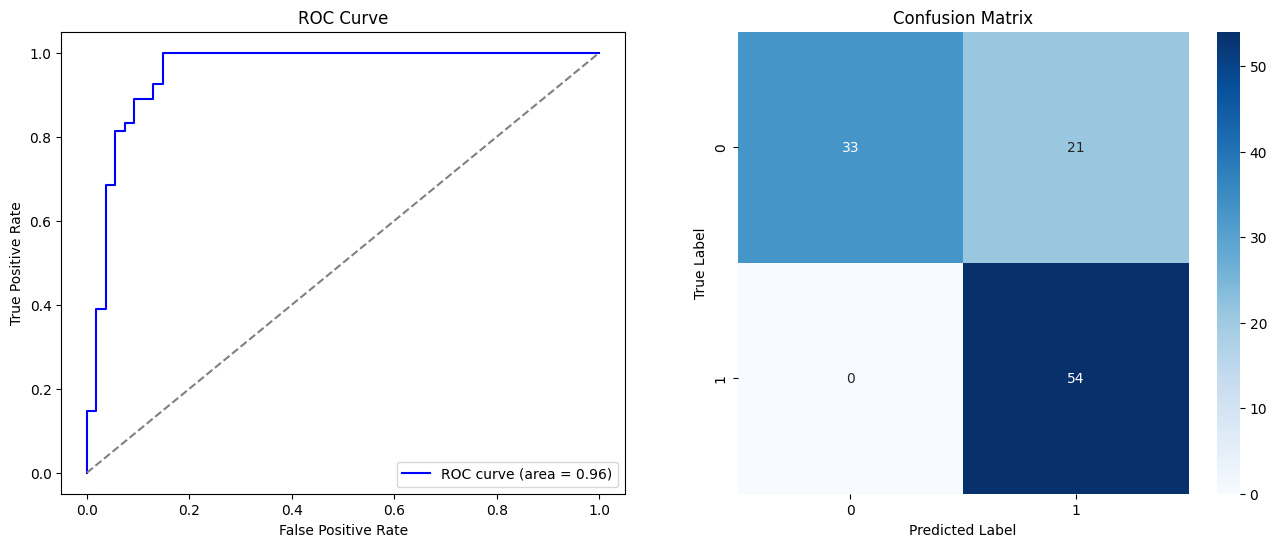

In [184]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import joblib
# === LOAD MODEL ===
model = joblib.load(model_path)

# === PREDICT ===
yTestPred = model.predict(X_test)
finalAccuracy = accuracy_score(y_test, yTestPred)
finalPrecision = precision_score(y_test, yTestPred)
finalRecall = recall_score(y_test, yTestPred)
finalF1 = f1_score(y_test, yTestPred)

print(f"Accuracy: {finalAccuracy:.4f}")
print(f"Precision: {finalPrecision:.4f}")
print(f"Recall: {finalRecall:.4f}")
print(f"F1-score: {finalF1:.4f}")

# ROC Curve
yProb = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, yProb)
roc_auc = auc(fpr, tpr)
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve')
ax_roc.legend(loc='lower right')
roc_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_roc.png")
plt.savefig(roc_plot_filename, dpi=800)
plt.close(fig_roc)

# Confusion Matrix
cm = confusion_matrix(y_test, yTestPred)
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax_cm)
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')
ax_cm.set_title('Confusion Matrix')
cm_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_cm.png")
plt.savefig(cm_plot_filename, dpi=800)
plt.close(fig_cm)

# Combined ROC + Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc='lower right')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax[1])
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_title('Confusion Matrix')
combined_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_roc_cm_combined.png")
plt.savefig(combined_plot_filename, dpi=800)
# plt.close(fig)

In [8]:
print(np.bincount(y_test.astype(int)))

[54 54]


In [5]:
print(yProb[:20])  # See the first 20 probabilities

[0.72150794 0.70350794 0.70578571 0.68507937 0.68507937 0.71407937
 0.71157937 0.71457937 0.69886508 0.69836508 0.68943651 0.73708874
 0.71145238 0.71033333 0.72586652 0.67435859 0.65279509 0.63983478
 0.75498557 0.76376335]


In [11]:
print("y_test unique values:", np.unique(y_test))
print("yTestPred unique values:", np.unique(yTestPred))


y_test unique values: [0. 1.]
yTestPred unique values: [1.]


In [12]:
# First: check probabilities again
print(yProb[:20])  # see if there are meaningful differences, e.g. [0.2, 0.6, 0.9, ...]

# Try threshold tuning
import numpy as np
best_thresh = 0.5  # You can search this later
yTestPred_thresh = (yProb >= best_thresh).astype(int)

# New metrics
print("Accuracy:", accuracy_score(y_test, yTestPred_thresh))
print("Precision:", precision_score(y_test, yTestPred_thresh))
print("Recall:", recall_score(y_test, yTestPred_thresh))
print("F1:", f1_score(y_test, yTestPred_thresh))


[0.72150794 0.70350794 0.70578571 0.68507937 0.68507937 0.71407937
 0.71157937 0.71457937 0.69886508 0.69836508 0.68943651 0.73708874
 0.71145238 0.71033333 0.72586652 0.67435859 0.65279509 0.63983478
 0.75498557 0.76376335]
Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1: 0.6666666666666666


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Try new threshold
threshold = 0.75
y_pred_adjusted = (yProb >= threshold).astype(int)

# Print updated scores
print(f"Threshold: {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("Precision:", precision_score(y_test, y_pred_adjusted))
print("Recall:", recall_score(y_test, y_pred_adjusted))
print("F1:", f1_score(y_test, y_pred_adjusted))


Threshold: 0.75
Accuracy: 0.8333333333333334
Precision: 0.8461538461538461
Recall: 0.8148148148148148
F1: 0.8301886792452831


In [16]:
from sklearn.metrics import f1_score
import numpy as np

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.4, 0.9, 0.01):
    preds = (yProb >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best threshold: {best_thresh:.2f} with F1: {best_f1:.4f}")


Best threshold: 0.74 with F1: 0.8376


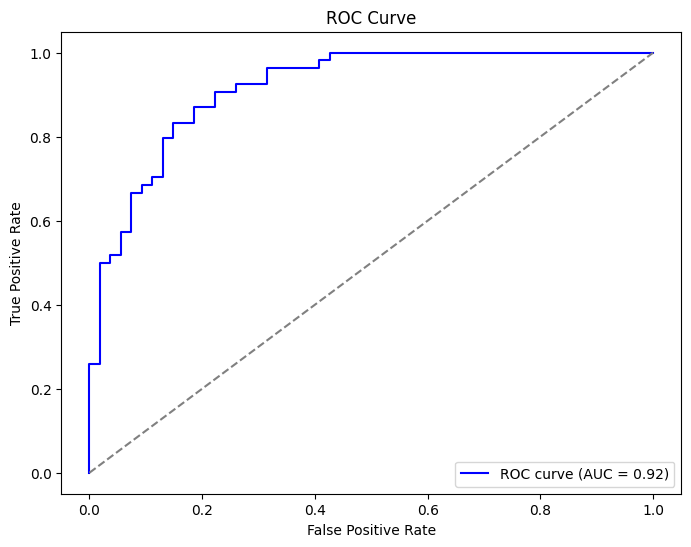

In [17]:
fpr, tpr, _ = roc_curve(y_test, yProb)
roc_auc = auc(fpr, tpr)

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve')
ax_roc.legend(loc='lower right')

roc_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_roc.png")
plt.savefig(roc_plot_filename, dpi=800)